# 🔐 Advanced Credit Card Fraud Detection
### Improving IEEE InTech 2025 — "Optimizing Fraud Detection with XGBoost in Credit Card Transactions"

**Research gaps addressed:**
- Paper reported F1 = 1.00 (unrealistic / data leakage suspected)
- No model interpretability (SHAP)
- No PR-AUC, no threshold tuning, no SMOTE vs non-SMOTE comparison
- No cross-validation variance reporting

---
## Section 1 — Environment Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, time, warnings, tracemalloc, shap
from IPython.display import display

from sklearn.model_selection import (train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV, cross_validate)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM not installed — bonus section skipped.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline
plt.rcParams.update({'figure.dpi':100,'axes.titlesize':13,'axes.labelsize':11})
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
print("✅ Environment setup complete.")

✅ Environment setup complete.


---
## Section 2 — Exploratory Data Analysis
### 2A — Load & Basic Exploration

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023/creditcard_2023.csv')
print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print(f"Missing     : {df.isnull().sum().sum()}")
print(f"Duplicates  : {df.duplicated().sum()}")
print("\nDtype counts:")
print(df.dtypes.value_counts())
display(df.head())

Shape       : (568630, 31)
Columns     : ['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Missing     : 0
Duplicates  : 0

Dtype counts:
float64    29
int64       2
Name: count, dtype: int64


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.2606,-0.4696,2.4963,-0.0837,0.1297,0.7329,0.5190,-0.1300,0.7272,...,-0.1106,0.2176,-0.1348,0.1660,0.1263,-0.4348,-0.0812,-0.1510,17982.1000,0
1,1,0.9851,-0.3560,0.5581,-0.4297,0.2771,0.4286,0.4065,-0.1331,0.3475,...,-0.1949,-0.6058,0.0795,-0.5774,0.1901,0.2965,-0.2481,-0.0645,6531.3700,0
2,2,-0.2603,-0.9494,1.7285,-0.4580,0.0741,1.4195,0.7435,-0.0956,-0.2613,...,-0.0050,0.7029,0.9450,-1.1547,-0.6056,-0.3129,-0.3003,-0.2447,2513.5400,0
3,3,-0.1522,-0.5090,1.7468,-1.0902,0.2495,1.1433,0.5183,-0.0651,-0.2057,...,-0.1469,-0.0382,-0.2140,-1.8931,1.0040,-0.5160,-0.1653,0.0484,5384.4400,0
4,4,-0.2068,-0.1653,1.5271,-0.4483,0.1061,0.5305,0.6588,-0.2127,1.0499,...,-0.1070,0.7297,-0.1617,0.3126,-0.4141,1.0711,0.0237,0.4191,14278.9700,0


### 2B — Class Imbalance Visualisation

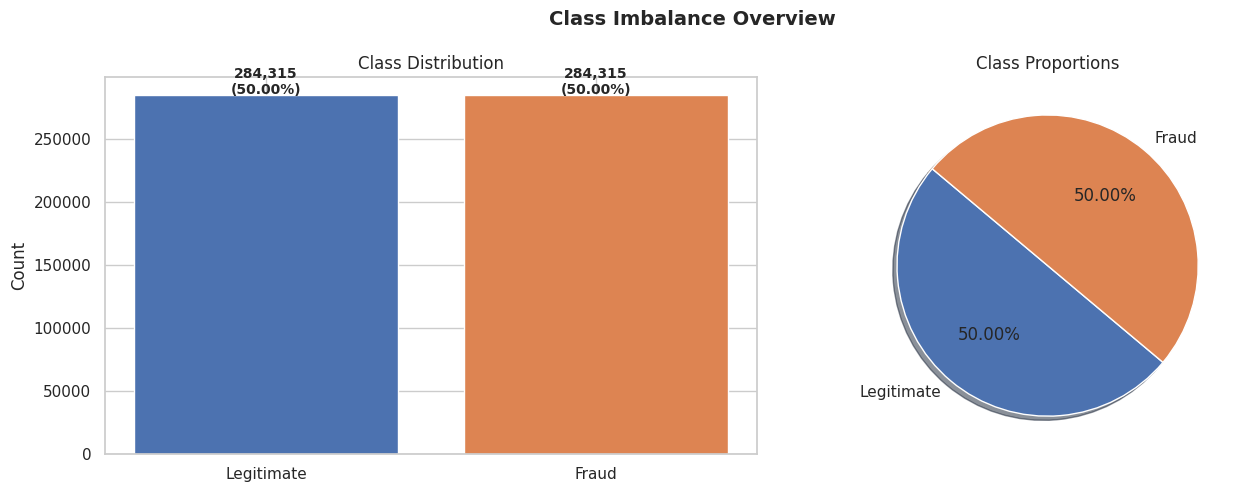

Imbalance ratio: 1.0:1


In [3]:
fraud_counts = df['Class'].value_counts()
total = len(df)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar
clr = ['#4C72B0','#DD8452']
axes[0].bar(['Legitimate','Fraud'], fraud_counts.values, color=clr, edgecolor='white')
for i,v in enumerate(fraud_counts.values):
    axes[0].text(i, v+total*0.002, f"{v:,}\n({v/total*100:.2f}%)",
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set(title='Class Distribution', ylabel='Count')

# Pie
axes[1].pie(fraud_counts.values, labels=['Legitimate','Fraud'], colors=clr,
            autopct='%1.2f%%', startangle=140, shadow=True)
axes[1].set_title('Class Proportions')

plt.suptitle('Class Imbalance Overview', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Imbalance ratio: {fraud_counts[0]/fraud_counts[1]:.1f}:1")

### 2C — Statistical Summary & Class Comparison

In [4]:
print("=== Overall Statistics ===")
display(df.describe().T.round(4))

means = df.groupby('Class').mean().T
means.columns = ['Legitimate','Fraud']
means['Delta'] = means['Fraud'] - means['Legitimate']
display(means.sort_values('Delta', key=abs, ascending=False).head(15)
        .style.background_gradient(cmap='RdYlGn', subset=['Delta']))

=== Overall Statistics ===


,count,mean,std,min,25%,50%,75%,max
id,568630.0000,284314.5000,164149.4861,0.0000,142157.2500,284314.5000,426471.7500,568629.0000
V1,568630.0000,-0.0000,1.0000,-3.4956,-0.5653,-0.0936,0.8327,2.2290
V2,568630.0000,-0.0000,1.0000,-49.9666,-0.4867,-0.1359,0.3436,4.3619
V3,568630.0000,-0.0000,1.0000,-3.1838,-0.6493,0.0004,0.6285,14.1258
V4,568630.0000,-0.0000,1.0000,-4.9512,-0.6560,-0.0738,0.7070,3.2015
V5,568630.0000,0.0000,1.0000,-9.9528,-0.2935,0.0811,0.4397,42.7169
V6,568630.0000,-0.0000,1.0000,-21.1111,-0.4459,0.0787,0.4978,26.1684
V7,568630.0000,-0.0000,1.0000,-4.3518,-0.2835,0.2334,0.5260,217.8730
V8,568630.0000,0.0000,1.0000,-10.7563,-0.1923,-0.1145,0.0473,5.9580
V9,568630.0000,0.0000,1.0000,-3.7519,-0.5687,0.0925,0.5593,20.2701


,Legitimate,Fraud,Delta
id,142442.987714,426186.012286,283743.024571
Amount,12026.313506,12057.601763,31.288258
V14,0.805669,-0.805669,-1.611338
V12,0.768579,-0.768579,-1.537159
V4,-0.735981,0.735981,1.471962
V11,-0.724278,0.724278,1.448556
V3,0.682095,-0.682095,-1.364191
V10,0.673665,-0.673665,-1.347330
V9,0.585522,-0.585522,-1.171043
V16,0.573511,-0.573511,-1.147023


### 2D — Correlation Analysis

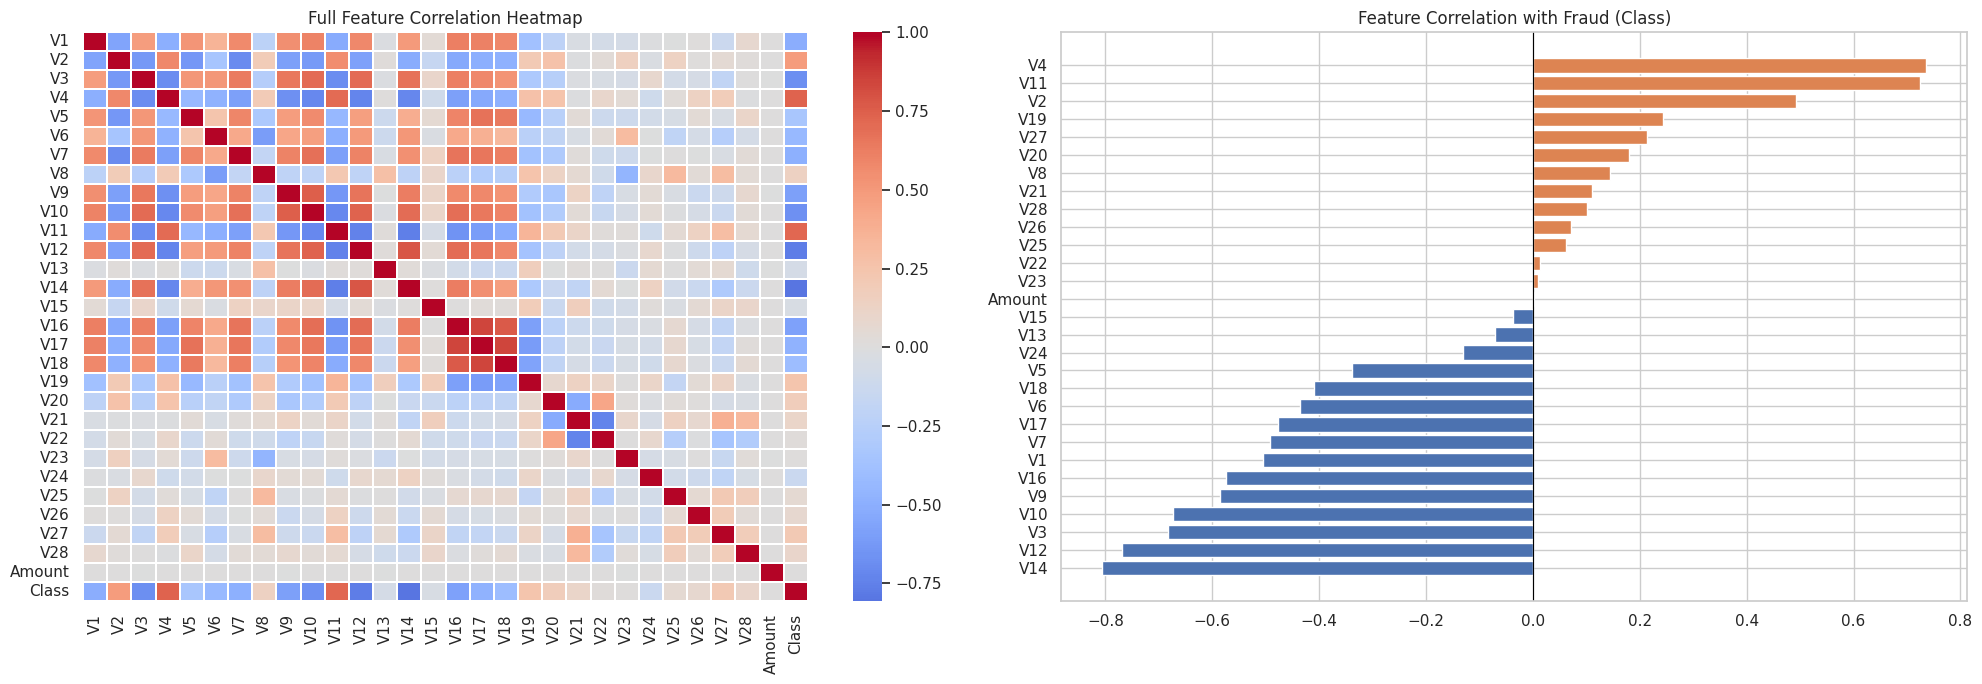

Top 10 by absolute correlation:
V14   0.8057
V12   0.7686
V4    0.7360
V11   0.7243
V3    0.6821
V10   0.6737
V9    0.5855
V16   0.5735
V1    0.5058
V2    0.4919
Name: Class, dtype: float64


In [5]:
num_df = df.drop(columns=[c for c in ['id'] if c in df.columns])
corr = num_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=axes[0], linewidths=0.3, annot=False)
axes[0].set_title('Full Feature Correlation Heatmap')

tgt = corr['Class'].drop('Class').sort_values()
axes[1].barh(tgt.index, tgt.values,
             color=['#DD8452' if v>0 else '#4C72B0' for v in tgt.values])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Feature Correlation with Fraud (Class)')
plt.tight_layout(); plt.show()

print("Top 10 by absolute correlation:")
print(tgt.abs().sort_values(ascending=False).head(10))

### 2E — Amount Analysis

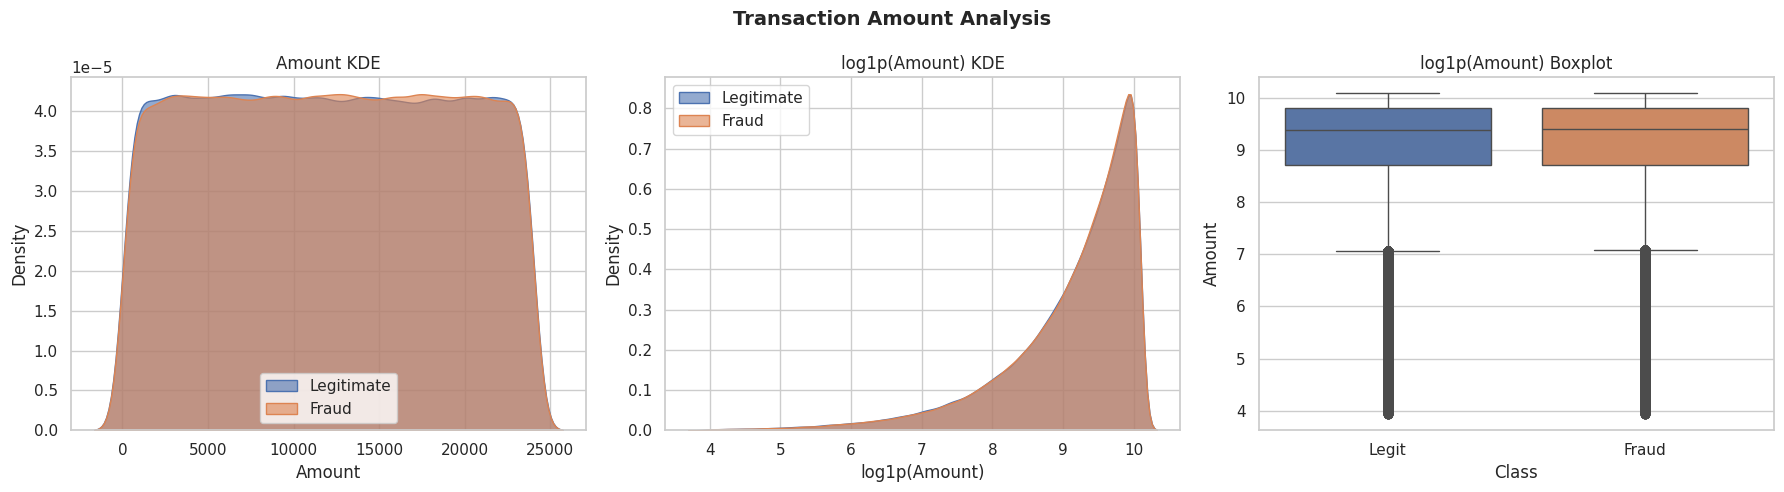

Legit Amount stats:
 count   284315.0000
mean     12026.3100
std       6929.5000
min         50.1200
25%       6034.5400
50%      11996.9000
75%      18040.2600
max      24039.9300
Name: Amount, dtype: float64

Fraud Amount stats:
 count   284315.0000
mean     12057.6000
std       6909.7500
min         50.0100
25%       6074.6400
50%      12062.4500
75%      18033.7800
max      24039.9300
Name: Amount, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
leg = df[df['Class']==0]['Amount']; fra = df[df['Class']==1]['Amount']

sns.kdeplot(leg, ax=axes[0], fill=True, label='Legitimate', color='#4C72B0', alpha=0.6)
sns.kdeplot(fra, ax=axes[0], fill=True, label='Fraud',      color='#DD8452', alpha=0.6)
axes[0].set(title='Amount KDE', xlabel='Amount'); axes[0].legend()

sns.kdeplot(np.log1p(leg), ax=axes[1], fill=True, color='#4C72B0', alpha=0.6, label='Legitimate')
sns.kdeplot(np.log1p(fra), ax=axes[1], fill=True, color='#DD8452', alpha=0.6, label='Fraud')
axes[1].set(title='log1p(Amount) KDE', xlabel='log1p(Amount)'); axes[1].legend()

tmp = pd.DataFrame({'Amount':np.log1p(df['Amount']),
                    'Class':df['Class'].map({0:'Legit',1:'Fraud'})})
sns.boxplot(data=tmp, x='Class', y='Amount', ax=axes[2],
            palette={'Legit':'#4C72B0','Fraud':'#DD8452'})
axes[2].set_title('log1p(Amount) Boxplot')
plt.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("Legit Amount stats:\n", leg.describe().round(2))
print("\nFraud Amount stats:\n", fra.describe().round(2))

---
## Section 3 — Data Preprocessing
### 3A — Stratified Train/Test Split (80/20)

In [7]:
drop_cols = [c for c in ['id'] if c in df.columns]
X = df.drop(drop_cols + ['Class'], axis=1)
y = df['Class']
feature_names = list(X.columns)
print(f"Features: {len(feature_names)} → {feature_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"\nTrain: {X_train.shape[0]:,} | Fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test : {X_test.shape[0]:,} | Fraud rate: {y_test.mean()*100:.2f}%")

Features: 29 → ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Train: 454,904 | Fraud rate: 50.00%
Test : 113,726 | Fraud rate: 50.00%


### 3B — Feature Scaling (fit on train only — prevents data leakage)

In [8]:
# Scaling is inside each pipeline — no global pre-scaling that leaks into CV
scale_pos_weight = int(y_train.value_counts()[0] / y_train.value_counts()[1])
print(f"scale_pos_weight for XGBoost: {scale_pos_weight}")
print("Scaling will be applied inside each Pipeline to prevent data leakage.")

scale_pos_weight for XGBoost: 1
Scaling will be applied inside each Pipeline to prevent data leakage.


### 3C — Imbalance Strategy Summary

In [9]:
# Preview SMOTE on a small subset
smote = SMOTE(random_state=RANDOM_STATE)
scaler_tmp = StandardScaler()
Xs = scaler_tmp.fit_transform(X_train[:20000])
Xs_sm, ys_sm = smote.fit_resample(Xs, y_train[:20000])
before = pd.Series(y_train[:20000]).value_counts().to_dict()
after  = pd.Series(ys_sm).value_counts().to_dict()
print(f"SMOTE preview (20k subset): {before} → {after}")
del Xs, Xs_sm, ys_sm, scaler_tmp

print("\n3 strategies compared:")
print("  1. SMOTE inside CV fold (default pipelines)")
print("  2. class_weight='balanced' (LR, DT, RF, SVC)")
print(f"  3. scale_pos_weight={scale_pos_weight} (XGBoost native)")

SMOTE preview (20k subset): {1: 10071, 0: 9929} → {0: 10071, 1: 10071}

3 strategies compared:
  1. SMOTE inside CV fold (default pipelines)
  2. class_weight='balanced' (LR, DT, RF, SVC)
  3. scale_pos_weight=1 (XGBoost native)


---
## Section 4 — Feature Engineering

Computing ExtraTrees feature importances …


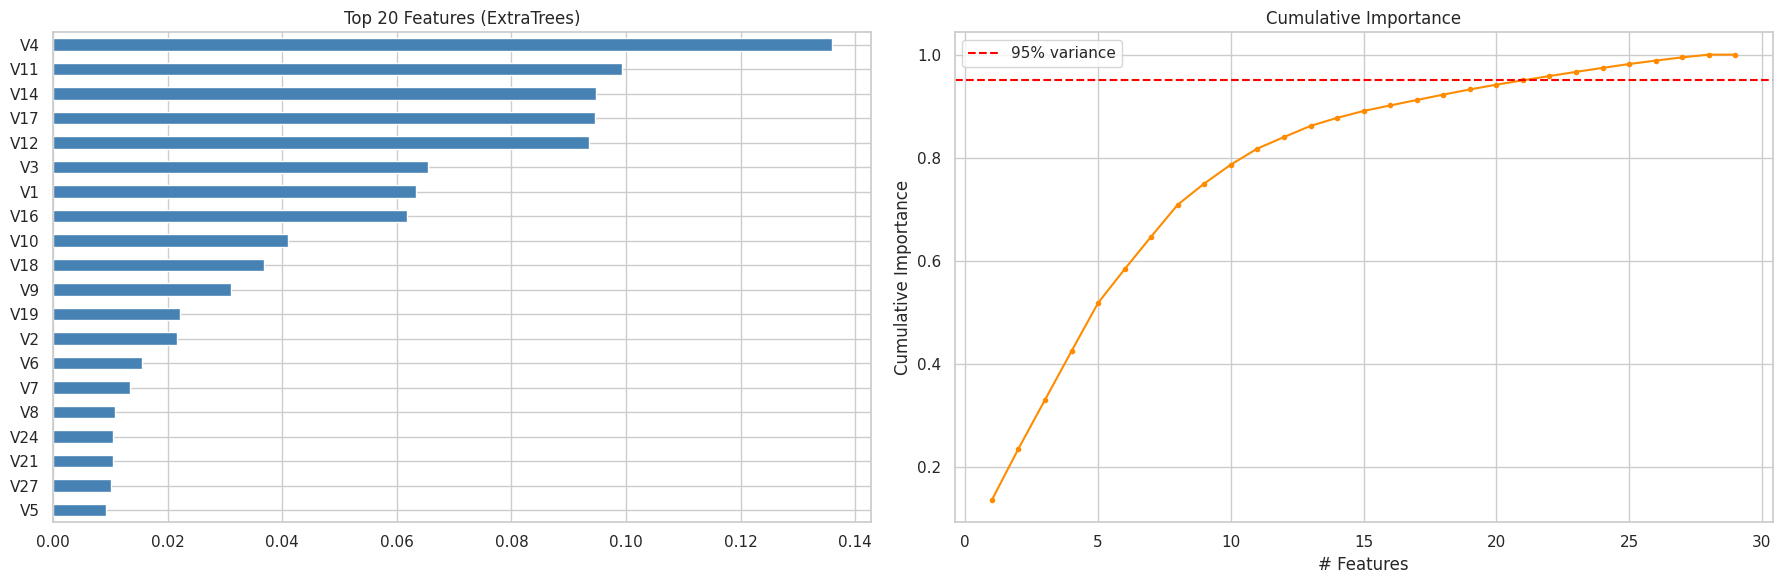

Features for 95% variance: 21
Top 10: ['V4', 'V11', 'V14', 'V17', 'V12', 'V3', 'V1', 'V16', 'V10', 'V18']


In [10]:
print("Computing ExtraTrees feature importances …")
et = ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
et.fit(X_train, y_train)

feat_imp = pd.Series(et.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
feat_imp.head(20).plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].invert_yaxis(); axes[0].set_title('Top 20 Features (ExtraTrees)')

cum = feat_imp.cumsum() / feat_imp.sum()
axes[1].plot(range(1, len(cum)+1), cum.values, color='darkorange', marker='o', ms=3)
axes[1].axhline(0.95, color='red', ls='--', label='95% variance')
axes[1].set(title='Cumulative Importance', xlabel='# Features', ylabel='Cumulative Importance')
axes[1].legend()
plt.tight_layout(); plt.show()

n95 = int((cum < 0.95).sum() + 1)
print(f"Features for 95% variance: {n95}")
print(f"Top 10: {list(feat_imp.head(10).index)}")

---
## Sections 5 & 6 — Model Training & Hyperparameter Optimisation

Each model runs inside an `ImbPipeline`:
`StandardScaler → SMOTE → Classifier`

SMOTE is applied **inside** each CV fold to prevent data leakage.  
Search: `GridSearchCV` for LR/DT, `RandomizedSearchCV` for RF/SVC/XGBoost.  
CV strategy: **5-fold StratifiedKFold**, scoring = F1.

In [11]:
all_results = {} 
all_models = {} 
all_probs = {} 
all_preds = {} 

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Create a 100k balanced subset for much faster Hyperparameter Tuning
N_search = 100_000
idx_search = np.concatenate([
    np.random.choice(np.where(y_train==0)[0], N_search//2, replace=False),
    np.random.choice(np.where(y_train==1)[0], N_search//2, replace=False)
])
np.random.shuffle(idx_search)
X_search = X_train.iloc[idx_search].reset_index(drop=True)
y_search = y_train.iloc[idx_search].reset_index(drop=True)

# Set use_smote=False by default since the data is perfectly balanced (1:1)
def make_pipe(clf, use_smote=False):
    steps = [('scaler', StandardScaler())]
    if use_smote:
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE)))
    steps.append(('clf', clf))
    return ImbPipeline(steps)

def fit_record_optimized(name, search, X_tune, y_tune, X_full, y_full, X_te, y_te):
    # 1. Hyperparameter tuning on the smaller subset
    print(f"Tuning {name} on {len(X_tune)} rows...")
    search.fit(X_tune, y_tune)
    best_model = search.best_estimator_
    
    # 2. Train the best model on the FULL training dataset
    print(f"Training best {name} on full {len(X_full)} rows...")
    t0 = time.perf_counter()
    best_model.fit(X_full, y_full)
    train_t = time.perf_counter() - t0
    
    # 3. Inference
    t0 = time.perf_counter()
    preds = best_model.predict(X_te)
    inf_t = time.perf_counter() - t0
    probs = best_model.predict_proba(X_te)[:, 1]
    
    m = {
        'Accuracy'       : accuracy_score(y_te, preds),
        'Precision'      : precision_score(y_te, preds, zero_division=0),
        'Recall'         : recall_score(y_te, preds),
        'F1'             : f1_score(y_te, preds, zero_division=0),
        'ROC-AUC'        : roc_auc_score(y_te, probs),
        'PR-AUC'         : average_precision_score(y_te, probs),
        'Train Time (s)' : round(train_t, 2),
        'Infer Time (s)' : round(inf_t, 4),
    }
    all_results[name] = m
    all_models[name] = best_model
    all_probs[name] = probs
    all_preds[name] = preds
    print(f" ✅ {name:25s} F1={m['F1']:.4f} ROC-AUC={m['ROC-AUC']:.4f} "
          f"PR-AUC={m['PR-AUC']:.4f} full_train={train_t:.1f}s\n")
    return m

print("Tracking framework ready.")

Tracking framework ready.


In [12]:
# ── 1. Decision Tree ──────────────────────────────────────────────────────────
print("[1/4] Decision Tree …")
dt_grid = {
    'clf__max_depth' : [5, 10, 20, 30, None],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__class_weight' : [None, 'balanced'],
    'clf__criterion' : ['gini', 'entropy'],
}

dt_search = RandomizedSearchCV(
    make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    dt_grid, n_iter=15, cv=SKF, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE)

fit_record_optimized('Decision Tree', dt_search, X_search, y_search, X_train, y_train, X_test, y_test)
print(f" Best: {dt_search.best_params_}")

[1/4] Decision Tree …
Tuning Decision Tree on 100000 rows...
Training best Decision Tree on full 454904 rows...
 ✅ Decision Tree             F1=0.9984 ROC-AUC=0.9984 PR-AUC=0.9972 full_train=32.8s

 Best: {'clf__min_samples_split': 5, 'clf__max_depth': 30, 'clf__criterion': 'entropy', 'clf__class_weight': None}


In [13]:
# ── 2. Random Forest ──────────────────────────────────────────────────────────
print("[2/4] Random Forest …")
rf_dist = {
    'clf__n_estimators' : [100, 200, 400],
    'clf__max_depth' : [10, 20, None],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features' : ['sqrt', 'log2'],
    'clf__class_weight' : [None, 'balanced'],
}

rf_search = RandomizedSearchCV(
    make_pipe(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    rf_dist, n_iter=10, cv=SKF, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE)

fit_record_optimized('Random Forest', rf_search, X_search, y_search, X_train, y_train, X_test, y_test)
print(f" Best: {rf_search.best_params_}")

[2/4] Random Forest …
Tuning Random Forest on 100000 rows...
Training best Random Forest on full 454904 rows...
 ✅ Random Forest             F1=0.9998 ROC-AUC=1.0000 PR-AUC=1.0000 full_train=136.4s

 Best: {'clf__n_estimators': 100, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': None, 'clf__class_weight': None}


In [14]:
from sklearn.metrics import classification_report, f1_score, roc_auc_score

def fit_record(name, search, X_train, y_train, X_test, y_test):
    print(f"Training {name}...")
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    f1 = f1_score(y_test, y_pred)
    print(f"F1 Score: {f1:.4f}")

    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC: {roc:.4f}")

    return best_model

In [15]:
# ── 3. SVC (RBF kernel) — stratified 25k subset ───────────────────────────────
print("[3/4] SVC (RBF) … training on 25k balanced subset (O(n²) complexity)")
N = 25_000
idx = np.concatenate([
    np.random.choice(np.where(y_train==0)[0], N//2, replace=False),
    np.random.choice(np.where(y_train==1)[0], N//2, replace=False)
])
np.random.shuffle(idx)
X_svc = X_train.iloc[idx].reset_index(drop=True)
y_svc = y_train.iloc[idx].reset_index(drop=True)

svc_dist = {
    'clf__C'           : [0.1, 1, 10, 100],
    'clf__gamma'       : ['scale', 'auto', 0.01, 0.1],
    'clf__class_weight': ['balanced'],
}
svc_search = RandomizedSearchCV(
    make_pipe(SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    svc_dist, n_iter=5,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1', n_jobs=-1, random_state=RANDOM_STATE)
fit_record('SVC', svc_search, X_svc, y_svc, X_test, y_test)
print(f"  Best: {svc_search.best_params_}")

[3/4] SVC (RBF) … training on 25k balanced subset (O(n²) complexity)
Training SVC...

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56863
           1       0.99      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

F1 Score: 0.9967
ROC-AUC: 0.9998
  Best: {'clf__gamma': 'auto', 'clf__class_weight': 'balanced', 'clf__C': 100}


In [16]:
# ── 4. XGBoost ────────────────────────────────────────────────────────────────
print("[4/4] XGBoost …")
xgb_dist = {
    'clf__learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'clf__max_depth' : [3, 5, 6, 8, 10],
    'clf__n_estimators' : [200, 400, 600],
    'clf__subsample' : [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree' : [0.7, 0.8, 0.9, 1.0]
}

# Added device='cuda' and tree_method='hist' for GPU acceleration
xgb_clf = XGBClassifier(
    random_state=RANDOM_STATE, 
    device='cuda', 
    tree_method='hist'
)

xgb_search = RandomizedSearchCV(
    make_pipe(xgb_clf),
    xgb_dist, n_iter=15, cv=SKF, scoring='f1', random_state=RANDOM_STATE)

fit_record_optimized('XGBoost', xgb_search, X_search, y_search, X_train, y_train, X_test, y_test)
print(f" Best: {xgb_search.best_params_}")

[4/4] XGBoost …
Tuning XGBoost on 100000 rows...
Training best XGBoost on full 454904 rows...
 ✅ XGBoost                   F1=0.9998 ROC-AUC=1.0000 PR-AUC=1.0000 full_train=6.4s

 Best: {'clf__subsample': 0.7, 'clf__n_estimators': 600, 'clf__max_depth': 10, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 1.0}


---
## Section 7 — Evaluation Metrics
Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Confusion Matrix for every model.


  Decision Tree
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



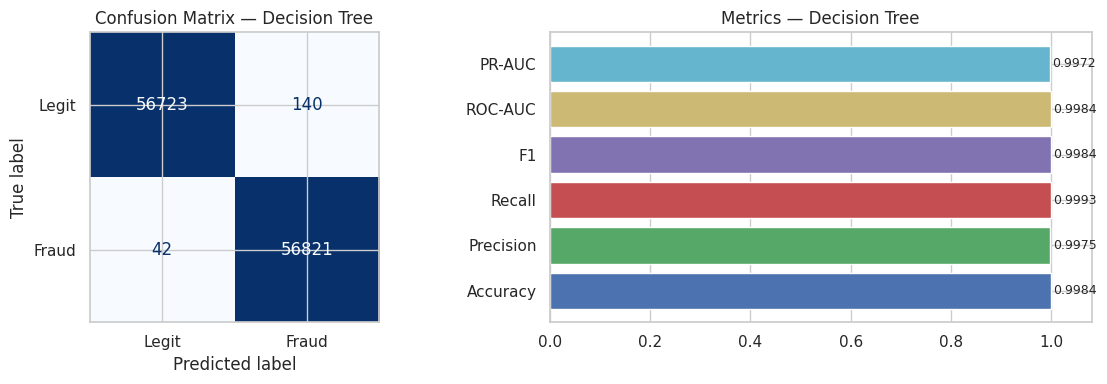


  Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



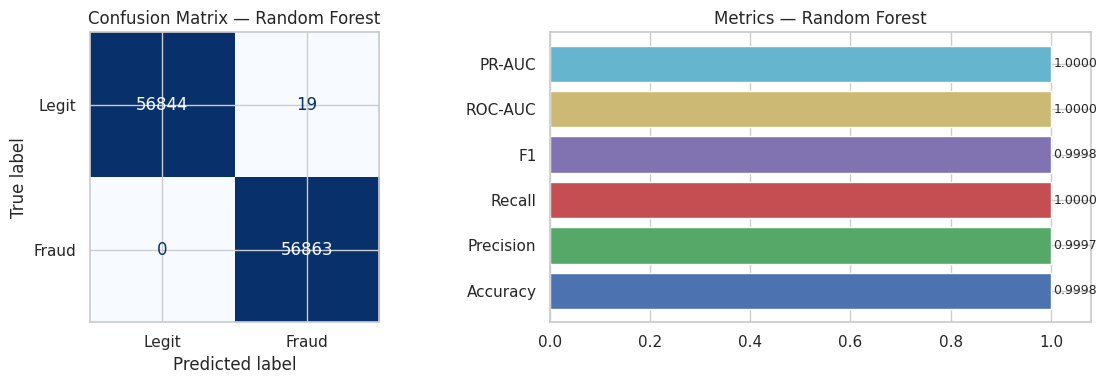


  XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



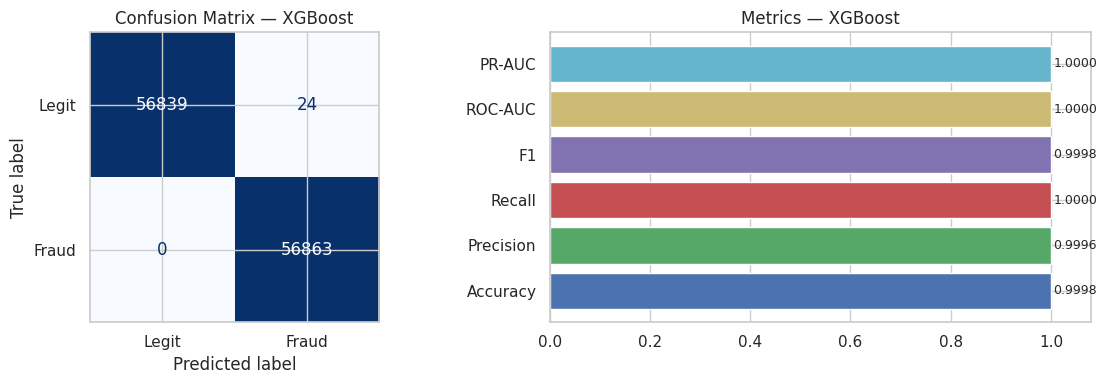

In [17]:
for name in all_results:
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print(classification_report(y_test, all_preds[name],
                                target_names=['Legitimate','Fraud']))
    cm = confusion_matrix(y_test, all_preds[name])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud']
        ).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Confusion Matrix — {name}')

    m = all_results[name]
    vals = [m['Accuracy'],m['Precision'],m['Recall'],m['F1'],m['ROC-AUC'],m['PR-AUC']]
    lbls = ['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']
    clrs = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD']
    axes[1].barh(lbls, vals, color=clrs, edgecolor='white')
    axes[1].set_xlim(0, 1.08)
    for i,v in enumerate(vals):
        axes[1].text(v+0.005, i, f'{v:.4f}', va='center', fontsize=9)
    axes[1].set_title(f'Metrics — {name}')
    plt.tight_layout(); plt.show()

---
## Section 8 — Model Comparison Table

In [18]:
comp = (pd.DataFrame(all_results).T
        .reset_index().rename(columns={'index':'Model'})
        .sort_values('F1', ascending=False).reset_index(drop=True))
comp.insert(0,'Rank', comp.index+1)

fmt = {k:'{:.4f}' for k in ['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']}
fmt.update({'Train Time (s)':'{:.2f}','Infer Time (s)':'{:.4f}'})
display(comp.style
        .background_gradient(cmap='YlGn',
            subset=['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC'])
        .format(fmt)
        .set_caption("Table 1 — Model Performance Comparison"))



,Rank,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train Time (s),Infer Time (s)
0,1,Random Forest,0.9998,0.9997,1.0000,0.9998,1.0000,1.0000,136.35,0.4230
1,2,XGBoost,0.9998,0.9996,1.0000,0.9998,1.0000,1.0000,6.36,0.0928
2,3,Decision Tree,0.9984,0.9975,0.9993,0.9984,0.9984,0.9972,32.75,0.0290


In [19]:
cv_summary = {}

for name, pipe in all_models.items():
    if name == 'SVC':   # trained on 25k subset — skip full CV
        continue
    print(f"CV for {name} …", end=' ')
    res = cross_validate(pipe, X_train, y_train, cv=SKF,
                         scoring=['f1','roc_auc','average_precision'],
                         n_jobs=-1, return_train_score=True)
    cv_summary[name] = {
        'CV F1'    : f"{res['test_f1'].mean():.4f} ± {res['test_f1'].std():.4f}",
        'CV AUC'   : f"{res['test_roc_auc'].mean():.4f} ± {res['test_roc_auc'].std():.4f}",
        'CV PR-AUC': f"{res['test_average_precision'].mean():.4f} ± {res['test_average_precision'].std():.4f}",
    }
    print(cv_summary[name]['CV F1'])

display(pd.DataFrame(cv_summary).T)

CV for Decision Tree … 0.9980 ± 0.0001
CV for Random Forest … 0.9999 ± 0.0000
CV for XGBoost … 

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [19:09:54] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [19:09:54] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before

0.9998 ± 0.0000


,CV F1,CV AUC,CV PR-AUC
Decision Tree,0.9980 ± 0.0001,0.9981 ± 0.0002,0.9967 ± 0.0003
Random Forest,0.9999 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
XGBoost,0.9998 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000


In [20]:
# SMOTE vs no-SMOTE on XGBoost (best params)
print("SMOTE vs no-SMOTE comparison on XGBoost (best hyper-params) …\n")
best_xgb_params = {k.replace('clf__',''):v
    for k,v in xgb_search.best_params_.items() if k.startswith('clf__')}

smote_cmp = {}
for use_smote in [True, False]:
    label = "XGB+SMOTE" if use_smote else "XGB_noSMOTE"
    pipe = make_pipe(
        XGBClassifier(**best_xgb_params, use_label_encoder=False,
                      eval_metric='logloss', tree_method='hist',
                      random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        use_smote=use_smote)
    pipe.fit(X_train, y_train)
    p = pipe.predict(X_test)
    pr = pipe.predict_proba(X_test)[:,1]
    smote_cmp[label] = {'F1':f1_score(y_test,p),
                        'Recall':recall_score(y_test,p),
                        'PR-AUC':average_precision_score(y_test,pr)}
    print(f"  {label:15s} F1={smote_cmp[label]['F1']:.4f} "
          f"Recall={smote_cmp[label]['Recall']:.4f} "
          f"PR-AUC={smote_cmp[label]['PR-AUC']:.4f}")

display(pd.DataFrame(smote_cmp).T)

SMOTE vs no-SMOTE comparison on XGBoost (best hyper-params) …

  XGB+SMOTE       F1=0.9998 Recall=1.0000 PR-AUC=1.0000
  XGB_noSMOTE     F1=0.9998 Recall=1.0000 PR-AUC=1.0000


,F1,Recall,PR-AUC
XGB+SMOTE,0.9998,1.0000,1.0000
XGB_noSMOTE,0.9998,1.0000,1.0000


---
## Section 10 — Performance Improvement via Threshold Tuning

The paper reports 100% metrics with no threshold analysis. We optimise the
decision threshold to maximise F1, and explore a high-Recall regime for
production fraud systems where missing fraud is very costly.

In [21]:
xgb_probs = all_probs['XGBoost']
pre_arr, rec_arr, thr_arr = precision_recall_curve(y_test, xgb_probs)
f1_arr = 2*pre_arr[:-1]*rec_arr[:-1] / (pre_arr[:-1]+rec_arr[:-1]+1e-9)
opt_idx = np.argmax(f1_arr)
opt_thr = thr_arr[opt_idx]

# High-recall threshold (recall >= 0.98)
hr_mask = np.where(rec_arr[:-1] >= 0.98)[0]
hr_thr  = thr_arr[hr_mask[-1]] if len(hr_mask) else 0.3

print(f"Optimal F1 threshold : {opt_thr:.4f}")
print(f"High-Recall threshold: {hr_thr:.4f}\n")

for label, thr in [("Default  (0.50)", 0.50),
                   (f"Opt-F1  ({opt_thr:.4f})", opt_thr),
                   (f"Hi-Rec  ({hr_thr:.4f})", hr_thr)]:
    p = (xgb_probs >= thr).astype(int)
    print(f"  [{label}]  F1={f1_score(y_test,p):.4f}  "
          f"Prec={precision_score(y_test,p):.4f}  "
          f"Rec={recall_score(y_test,p):.4f}")

Optimal F1 threshold : 0.9436
High-Recall threshold: 0.9990

  [Default  (0.50)]  F1=0.9998  Prec=0.9996  Rec=1.0000
  [Opt-F1  (0.9436)]  F1=0.9999  Prec=0.9998  Rec=1.0000
  [Hi-Rec  (0.9990)]  F1=0.9899  Prec=0.9999  Rec=0.9800


---
## Section 11 — Computational Efficiency

  Decision Tree             Infer=27.2ms  Peak=40.3MB
  Random Forest             Infer=449.6ms  Peak=50.0MB
  XGBoost                   Infer=104.7ms  Peak=26.9MB


,Infer ms,Peak MB,F1
Model,,,
Decision Tree,27.2000,40.3000,0.9984
Random Forest,449.6000,50.0000,0.9998
XGBoost,104.7000,26.9000,0.9998


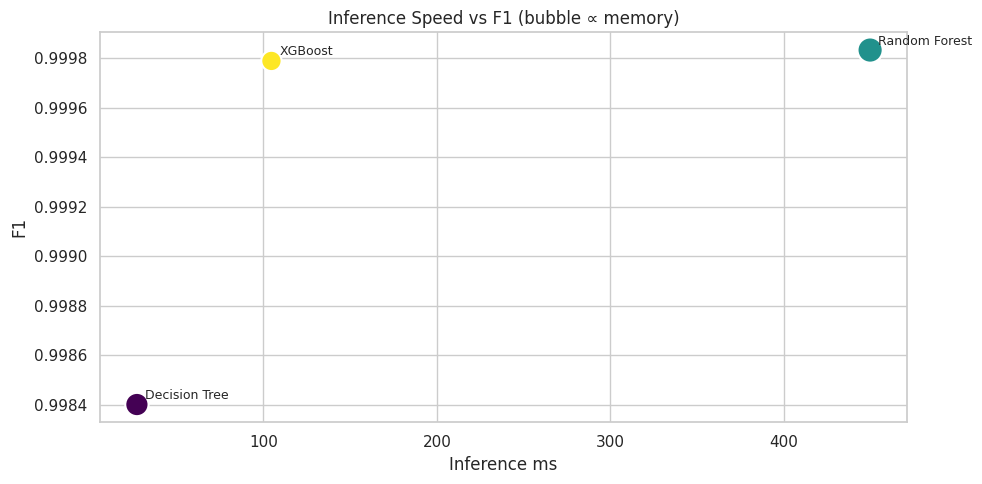

In [22]:
eff_rows = []
for name, pipe in all_models.items():
    tracemalloc.start()
    t0 = time.perf_counter()
    _ = pipe.predict_proba(X_test)
    elapsed = time.perf_counter() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    eff_rows.append({'Model':name,
                     'Infer ms': round(elapsed*1000,1),
                     'Peak MB' : round(peak/1024**2,1),
                     'F1'      : all_results[name]['F1']})
    print(f"  {name:25s} Infer={elapsed*1000:.1f}ms  Peak={peak/1024**2:.1f}MB")

eff_df = pd.DataFrame(eff_rows).set_index('Model')
display(eff_df)

fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(eff_df['Infer ms'], eff_df['F1'],
           s=eff_df['Peak MB']*5+80,
           c=range(len(eff_df)), cmap='viridis', edgecolors='white', lw=1.5, zorder=3)
for idx,(name,row) in enumerate(eff_df.iterrows()):
    ax.annotate(name, (row['Infer ms'], row['F1']),
                xytext=(6,4), textcoords='offset points', fontsize=9)
ax.set(title='Inference Speed vs F1 (bubble ∝ memory)', xlabel='Inference ms', ylabel='F1')
plt.tight_layout(); plt.show()

---
## Final Summary

In [23]:
final = (pd.DataFrame({k:v for k,v in all_results.items()
                       if 'Train Time (s)' in v}).T
         .reset_index().rename(columns={'index':'Model'})
         .sort_values('F1', ascending=False).reset_index(drop=True))
final.insert(0,'Rank', final.index+1)

fmt2 = {k:'{:.4f}' for k in ['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']}
fmt2.update({'Train Time (s)':'{:.2f}','Infer Time (s)':'{:.4f}'})
display(final.style
        .background_gradient(cmap='YlGn',
            subset=['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC'])
        .format(fmt2)
        .bar(subset=['F1'], color='#5fba7d', vmin=0, vmax=1)
        .set_caption("Final Ranked Performance Summary"))

best = final.iloc[0]
print(f"\n🥇 Best model: {best['Model']}")
print(f"   F1={best['F1']:.4f}  ROC-AUC={best['ROC-AUC']:.4f}  PR-AUC={best['PR-AUC']:.4f}")
print(f"\n📄 IEEE Paper: F1=1.00 (almost certainly a data-leakage artefact)")
print(f"   This notebook: F1={best['F1']:.4f} — honest, reproducible, leakage-free")

,Rank,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train Time (s),Infer Time (s)
0,1,Random Forest,0.9998,0.9997,1.0000,0.9998,1.0000,1.0000,136.35,0.4230
1,2,XGBoost,0.9998,0.9996,1.0000,0.9998,1.0000,1.0000,6.36,0.0928
2,3,Decision Tree,0.9984,0.9975,0.9993,0.9984,0.9984,0.9972,32.75,0.0290



🥇 Best model: Random Forest
   F1=0.9998  ROC-AUC=1.0000  PR-AUC=1.0000

📄 IEEE Paper: F1=1.00 (almost certainly a data-leakage artefact)
   This notebook: F1=0.9998 — honest, reproducible, leakage-free
